In [1]:
# from solve_gwf_1D import solve_gwf_1D
import os
import numpy as np
import torch
import h5py
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.fft import idct
from helper import *
from forwardmodel import *

In [2]:
# level sets for wave speed: see develope_sample_joint.ipynb to understand where these number come from
c_high = np.exp(0.27)
c_low  = np.exp(-0.27)


In [3]:
sigma_obs_noise=5e-3
sigma=sigma_obs_noise
beta=0.15

In [4]:
def sample_prior(alpha, tau, N, scale):
    """
    Python version of the MATLAB function:

        function U = gaussrnd(alpha,tau,N)
            xi   = normrnd(0,1,1,N);
            K1   = 0:N-1;
            coef = (pi^2*(K1.^2) + tau^2).^(-alpha/2);
            L    = sqrt(N) * coef. *xi * scale ;
            L(1) = 0;
            U    = idct(L,'Type',2);
        end
    """

    # Random variables in KL expansion
    xi = np.random.normal(loc=0.0, scale=1.0, size=N)

    # (square root of) eigenvalues
    k = np.arange(N)
    coef = (np.pi**2 * (k**2) + tau**2)**(-alpha / 2.0)

    # KL coefficients
    L = np.sqrt(N) * coef * xi * scale 
    L[0] = 0.0

    # Inverse DCT-II (to match MATLAB's idct(...,'Type',2))
    U = idct(L, type=2, norm='ortho')

    return U


In [5]:
# posterior samples options:
Debug = False
if Debug==False:
    burnin=100_000
    n_samples=2_500_000+burnin
else:
    burnin=100
    n_samples=10+burnin

In [6]:

path = "./../../../Data/Experiment7/samples_wave_center.npz"
N=100


with np.load(path) as data:
    # arrays
    U_samples = data["U"]
    arrivals = data["arrival"]
    x_nodes = data["x_nodes"]
    t_grid  = data["t_grid"]

    recv_idx = data["recv_idx"]
    x_recv   = data["x_recv"]

    time_idx = data["time_idx"]
    t_recv   = data["t_recv"]

    # scalars
    alpha = data["alpha"].item()
    tau   = data["tau"].item()
    scale = data["scale"].item()

    dt = data["dt"].item()
    T  = data["T"].item()
    L  = data["L"].item()
    f0 = data["f0"].item()

    xs_frac = data["xs_frac"].item()
    dt_obs  = data["dt_obs"].item()

iteration_true=0
u_true = U_samples[:,iteration_true]
y_true= arrivals[:,iteration_true]
y_obs=  y_true+ np.random.normal(size=y_true.shape)*sigma_obs_noise
dx=L/N

Np1= N+1 # number of grid points including the boundary
Lmat = build_L_neumann_matrix(Np1, dx) # solver setting (call once)
i = np.arange(1, N + 1)
x_center = (i - 0.5) / N  # shape (N,) x at the center points
np.savez("./../../../Data/Experiment7/wave_iteration"+str(iteration_true)+".npz", u_true=u_true, y_obs=y_obs, y_true=y_true)


In [7]:
N

100

In [8]:
dt

0.0002

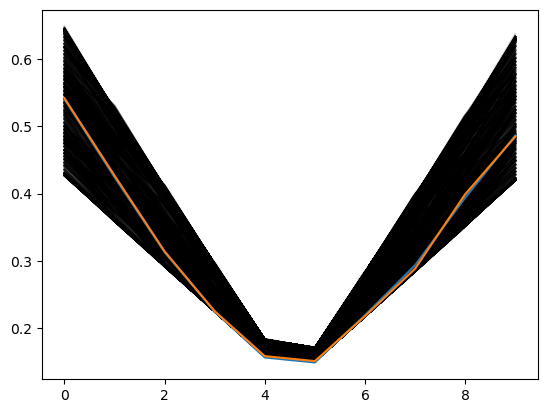

In [9]:
for i in range(1000):
    plt.plot(arrivals[:,i],color='black',alpha=0.2)
plt.plot(y_obs)
plt.plot(y_true) 

In [10]:
# # loading the pairs of data and the observed pressure and the true u.
# data = np.load("./../../../Data/Experiment4/joint_samples_wave.npz")
# U_samples = data["U"]        # (Np1, Nsample) 
# Y_store   = data["Y"]        # (Ny,  Nsample)

# # U_samples and Y_store are the samples from the joint distribution.

# x_nodes = data["x_nodes"]
# t_grid  = data["t_grid"]

# recv_idx = data["recv_idx"]
# x_recv   = data["x_recv"]

# time_idx = data["time_idx"]
# t_recv   = data["t_recv"]


# # a one line code to change a 400 dimensional observation into a Y that you can use for plot:
# # Y = y.reshape(len(time_idx), len(recv_idx))

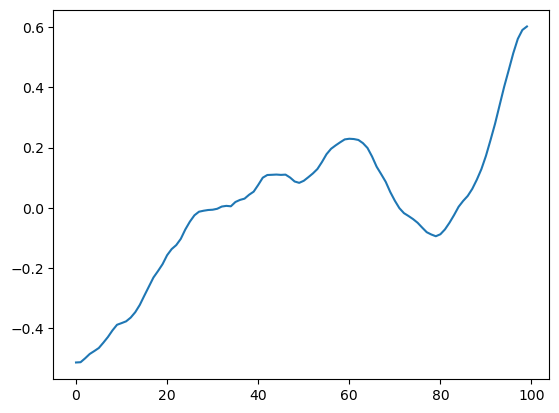

In [11]:
plt.plot(u_true)

In [12]:
# # forward model setting
# N=200 # number of intervals, number of points in the prior is 201
# dt = 1e-4
# L=1
# f0=20
# dx=L/N
# xs_frac=0.5
# T=1


In [13]:
# observation setting:
# observation:
# --- spatial receivers (indices on x grid) ---
# Nr = 4
# Nrp2 = Nr+2
# i = np.arange(0 , Nrp2)
# dx_obs=L/(Nr+1)
# ratio_obs_to_discritization= int(dx_obs/dx)
# x_nodes_rec = i*dx_obs

# recv_idx = (i*ratio_obs_to_discritization)[1:-1]
# x_recv = x_nodes[recv_idx]
# print(recv_idx)
# # --- time samples (indices on t grid) ---
# dt_obs = 0.01                     # observe every 0.01s
# time_idx = np.arange(0, int(T/dt_obs)) * int(dt_obs/dt)
# t_recv = time_idx * dt

# #-- obs noise



To define the likelihood, we need shear wave speed and solver and observation operator.


`x, t, P = solve_wave_1d(c=c, Lmat=Lmat, L=L, T=T, f0=f0, xs_frac=xs_frac, dt=dt)`

`Y,y=observe_from_grid(P, time_idx, recv_idx)`


In [14]:
def loglik(u, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt):
    """
    Compute log-likelihood for Darcy inverse problem:
        y = H p(u) + noise

    Inputs:
        u       : log-wave speed vector, including the points in the boundary
        y_obs   : observed time series of p at the recievers
        sigma   : noise std (iid)

    Returns:
        scalar log-likelihood (up to additive constant)
    """

    # Solve wave equation
    c = levelset_to_c_binary(u,c_high=c_high,c_low=c_low)
    # c=np.exp(u)
    x, t, P = solve_wave_1d(c=c, Lmat=Lmat, L=L, T=T, f0=f0, xs_frac=xs_frac, dt=dt)

    # Extract observations
    Y,y=observe_from_grid(P, time_idx, recv_idx) # 
    # y = y + scale_obs_noise * np.random.randn(y.size)
    ArrivalTimes=extract_arrival_times(Y, t_recv) # extracting the arrival times. 
    # Gaussian likelihood
    misfit = ArrivalTimes - y_obs
    return -0.5 * np.sum((misfit / sigma)**2)


In [15]:
# sigma=1e-6

In [16]:
# loglik(u_true, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt)

In [17]:
# sigma

In [18]:
# beta=0.05
# u= sample_prior(alpha, tau, N, scale)
# u = np.interp(x_nodes, x_center, u)
# u=u_true

# xi_center = sample_prior(alpha, tau, N, scale)
# # interpolate:
# xi = np.interp(x_nodes, x_center, xi_center)
# u_prop = np.sqrt(1-beta**2)*u + beta*xi 
# plt.plot(u,label="true")
# plt.plot(u_prop)
# plt.legend()
# print(loglik(u, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt))
# print(loglik(u_prop, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt))

In [19]:
# loglik(u, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt)

add the parameters to the pcn

In [20]:
def pcn(loglik, alpha, tau, scale, N, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt, x_nodes, x_center, beta=0.1, n_samples=1000, burn=5000, thin=1, rng=None, u0=None):
    """
    N+1 is the dimension of the prior.

    
    """
    
    if rng is None:
        rng = np.random.default_rng()

    chain = np.zeros((n_samples, N))

    # initialize from the prior
    if u0 is None:
        u = sample_prior(alpha, tau, N, scale)              # sampling prior at the center of the grid points
        u_node        =  np.interp(x_nodes, x_center, u)         # interpolate to get u at the nodes.
    else:
        u = u0.copy()
        u_node        =  np.interp(x_nodes, x_center, u)
    logl_u = loglik(u_node, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt)

    accepts = 0

    for k in range(n_samples):

        xi_center = sample_prior(alpha, tau, N, scale)
        # interpolate:
        # xi = np.interp(x_nodes, x_center, xi_center)

        # proposal
        u_prop = np.sqrt(1-beta**2)*u + beta*xi_center
        # interpolate to get values on the node:

        u_prop_nodes = np.interp(x_nodes, x_center, u_prop)

        logl_prop = loglik(u_prop_nodes, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt)
        log_alpha = logl_prop - logl_u

        if np.log(rng.uniform()) < log_alpha:
            u = u_prop
            logl_u = logl_prop
            accepts += 1

        chain[k] = u

    print("Acceptance rate:", accepts / n_samples)
    return chain[burn::thin]


In [21]:
seed = 1373
rng = np.random.default_rng(seed)

In [22]:
print(f"alpha={alpha}, tau={tau}, scale={scale}, N={N}, sigma={sigma}")

alpha=2, tau=5, scale=10, N=100, sigma=0.005


In [23]:
N

100

In [45]:
chain = pcn (loglik, alpha, tau, scale, N, y_obs, sigma, Lmat, L, T, f0, xs_frac, dt, x_nodes, x_center, beta=beta, n_samples=n_samples, burn=burnin, thin=1, rng=rng, u0=u_true)

Acceptance rate: 0.07081818181818182


In [24]:
iteration_true

-1

In [46]:
chain.shape

(10000, 100)

In [47]:
np.savez("./../../../Data/Experiment7/pcn_chain"+str(beta)+"iteration_datapoint"+str(iteration_true)+".npz", chain=chain)

In [48]:
chain.shape

(10000, 100)

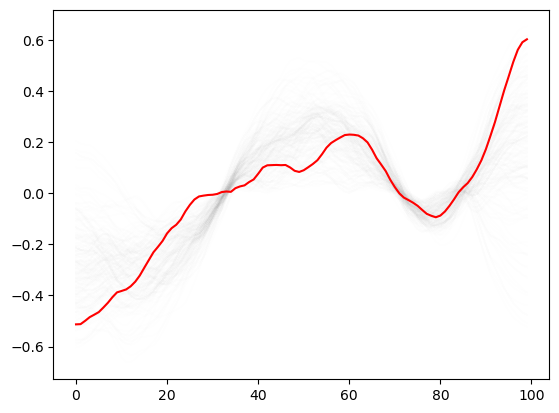

In [51]:
for i in range(0,chain.shape[0],50):
    plt.plot(chain[i,:],color='black',alpha=0.005)
plt.plot(u_true,color='red')